# Method Analysis

* VNeo method parsing adapted from from https://github.com/nickdelgrosso/XCaliburMethodReader/tree/master

## Imports

In [14]:
# import olefile
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import seaborn as sns
import os
import sys
import anndata as ad

%matplotlib inline

In [16]:
%load_ext autoreload
%autoreload 2

# Add parent directory to path to import modules from code/
sys.path.insert(0, os.path.abspath('..'))

from vneo_method import VNeoMethod
from lc_method_collection import VNeoMethodCollection
from ms_method import MicroTOFMethod
from ms_method_collection import MSMethodCollection
from anndiannloader import DiannLoader as dl
from diann_collection import DiannCollection
from filters import filter_mask
from method_mapper import map_lcms_methods
import precursor_window_analysis as pwa

# from plotting import Plotter

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Base

In [17]:
source = 'base'

In [18]:
if source == 'base':
    base = '/hpc/projects/mass_spec/eileenwang/'

## Load LC Methods

#### LC Collection Object

In [19]:
lccollection = VNeoMethodCollection()

In [20]:
lccollection.add_methods_from_folder(f'{base}MethodOpt/LCMSmethodAnalysis/SampleData/methods/LC')

/hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/code/vneo_method.py:127: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  gradient_df[col] = pd.to_numeric(gradient_df[col], errors='ignore')
/hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/code/vneo_method.py:130: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  equil_df[col] = pd.to_numeric(equil_df[col], errors='ignore')


In [45]:
lccollection.methods['17p5m150nlv13'].runtime

17.5

<Axes: title={'center': 'Gradient Comparison: 17p5m150nlv13, 20p5m150nlv6'}, xlabel='time [min]', ylabel='Nominal [µl/min]'>

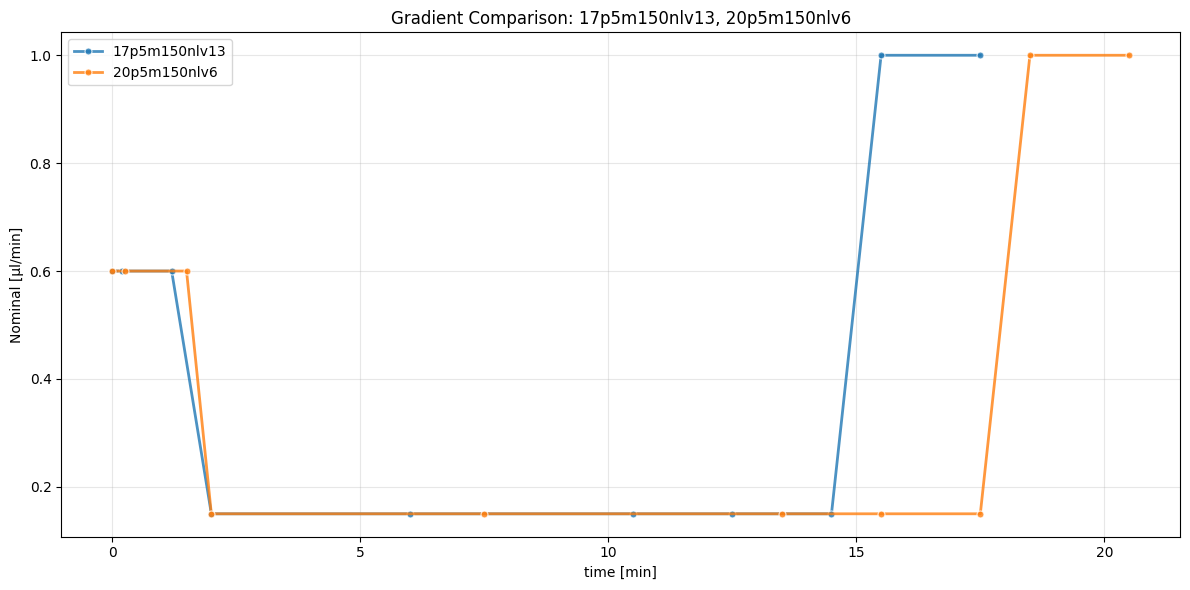

In [17]:
lccollection.plot_gradients(['17p5m150nlv13', '20p5m150nlv6'],
                        x_col = 'time [min]',
                        y_cols = ['Neo.PumpModule.Pump.Flow.Nominal [µl/min]'], 
                        twin_axes=True , 
                        markers=True
)

<Axes: title={'center': 'Gradient Comparison: 17p5m150nlv13, 23p75m150nlv16, 24m150nlThermo, 20m150nlv15, 20m150nlML30mA15v2, 36m150nlLong40, 18p6m200nlv28drop, 17p75m150nlv12, 23m150nlv21Zebra, 10m150nlRainmanA15-75, 11p5m150nlv9, 20m150nlML30mA15phospho4, 25m200nlv5, 20m150nlML23p5mA15v1, 20p5m150nlv14, 23p65m150nlv18Zebra, 25m150nlv5, 27m150nlv3, 19m200nlv26, 25m200nlv24, 19m200nlv25, 25m200nlv23, 19m200nlv27PC2drop, 16m150nlv8, 18p5m200nlv29, 20p5m150nlv6, 17p5m150nlv10, 18p6m200nlv30, 25m150nlv4, 25p15m150nlv22Zebra, 36m150nlSlow40, 23p65m150nlv19Zebra, 20p5m150nlv7, 25p15m150nlv20Zebra, 17p7m150nlv11, 23p75mHighACNWash150nlv17'}, xlabel='time [min]', ylabel='Value [%]'>

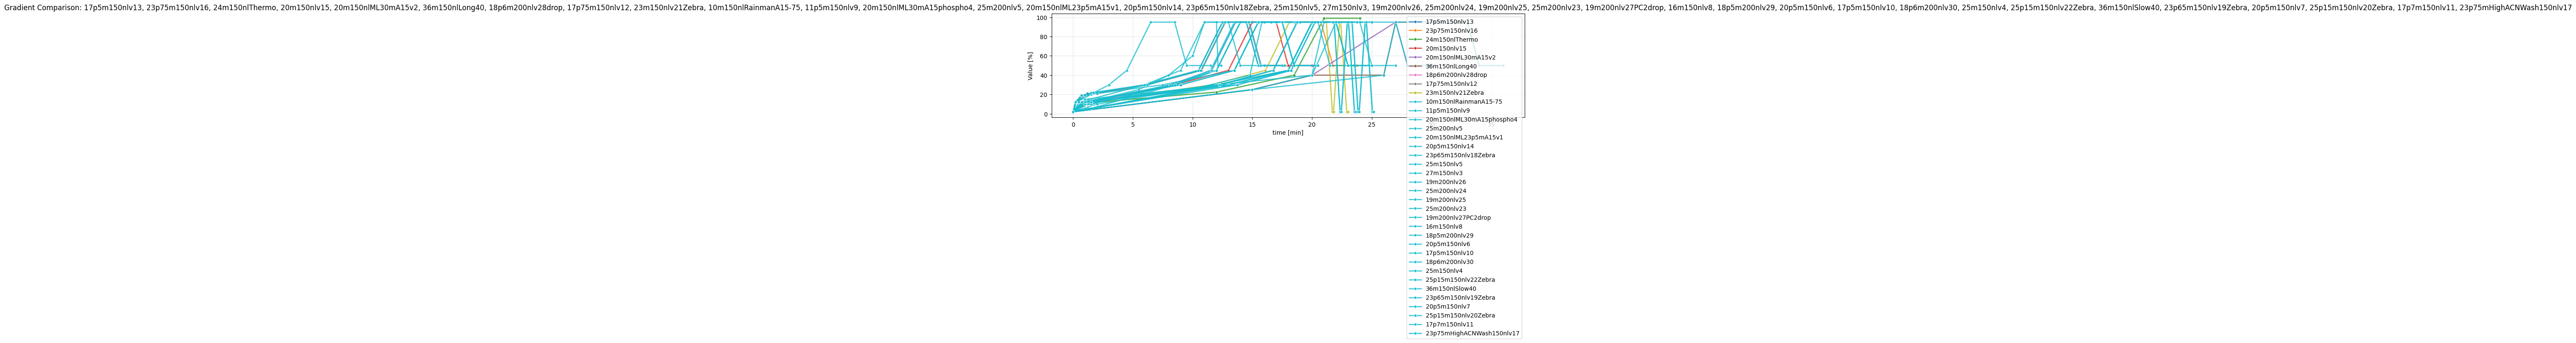

In [7]:
lccollection.plot_gradients(
                        x_col = 'time [min]',
                        y_cols = ['Neo.PumpModule.Pump.%B.Value [%]'], 
                        twin_axes=True , 
                        markers=True
)

## MS Methods

### Load MS Methods

In [53]:
# Intialize MS method collector object
mscollection = MSMethodCollection()

In [54]:
# # Method 1: Add single method with explicit name
# collection.add_method("/Users/eileen.wang/Desktop/diann/SampleData/methods/MS/DIA003.proteoscape.m")

# Method 2: Add from zip file (extracts and adds all methods inside)
mscollection.add_methods_from_folder(f"{base}/MethodOpt/LCMSmethodAnalysis/SampleData/methods/MS/msmethods.zip")
# collection.add_methods_from_paths(["/Users/eileen.wang/Desktop/diann/SampleData/methods/MS/DIA003.proteoscape.m"], overwrite = 'ignore')
msmethod_names = '\n'.join(mscollection.methods.keys())
# print(f"Loaded {len(mscollection)} methods: {msmethod_names}")


### MS Meth Summary

In [52]:
mscollection.methods.keys()

dict_keys(['DIA007', 'DIA004', 'DIA011QC2v1600', 'DIA011RT60expandedrangeV1600', 'DIA011V1600', 'DIA50ms007', 'DIA011QC2', 'DIA011RT40expandedrangeW83', 'DIA75msW82', 'DIA011RT85expandedrangeW83', 'DIA009', 'DIA015', 'DIA011', 'DIA011RT80expandedrangeW83', 'DIA011RT75', 'DIA006', 'DIA75msW82_C2', 'DIA011RT90expandedrangeW83', 'DIA011RT60expandedrangeW83', 'DIA002', 'DIA017', 'DIA011RT70expandedrangeW82', 'DIA011RT75expandedrange', 'DIA50msW122', 'DIA011expandedrange', 'DIA011RT70expandedrange', 'DIA60msW102_C2', 'DIA003', 'DIA50msW122_C2', 'DIA60msW103', 'DIA011RT60', 'DIA010', 'DIA50ms003', 'DIA011RT75expandedrangeW82', 'DIA011RT50expandedrangeW83', 'DIA012', 'DIA011RT70expandedrangeW62', 'DIA011RT70expandedrangeW83', 'DIA011RT75expandedrangeW83', 'MHC2DIA106_DIA001im', 'DIA016', 'DIA50msW122_1700v', 'DIA011RT70expandedrangeW63', 'DIA005', 'DIA014', 'DIA011RT75expandedrangeV1400', 'DIA018', 'DIA60msW102', 'DIA011RT75expandedrangeW63', 'DIA008', 'DIA75msW83_C2', 'DIA011QC2windows', 'DI

In [50]:
mscollection.methods['DIA003']
mscollection.methods['DIA011']

'DIA011RT75expandedrange'


BrukerMethod(DIA011.proteoscape.m, MS_params=412, DIA=21 windows, Synchro=None)

### Find Differences between methods

In [28]:
method = mscollection['DIA011RT70expandedrange']
value = method['Collision_GasSupply_Set']  # Direct access!
# cap_voltage = method['default_Source_CapillarySetValue']  # Positive only
windows = method['dia_windows']  # Direct access!


In [29]:
df = mscollection.to_dataframe(
    method_names=['DIA007', 'DIA016'],  # Optional: subset methods
    # param_names=['Collision_GasSupply_Set', 'dia_window_count'],  # Optional: subset params
    exclude_dia_windows=True  # Exclude DataFrame objects by default
)

In [30]:
df = mscollection.to_dataframe()

In [37]:
df.columns[50:100]

Index(['CollisionSweep_CollisionEnergy_Factor_Set',
       'CollisionSweep_CollisionRF_Factor_Set', 'CollisionSweep_Mode_Set',
       'CollisionSweep_Switch_Set', 'CollisionSweep_Time_Set',
       'CollisionSweep_TransferTime_Factor_Set', 'Collision_RF_Set',
       'Digitizer_SpectraRate', 'Digitizer_SpectraRateMode',
       'Digitizer_SpectraSampleTime', 'Digitizer_Summation',
       'IMSICC_ICC2_MaxTicTargetPercent', 'IMSICC_ICC2_MinAccuTime',
       'IMSICC_ICC2_ReferenceTicCapacity', 'IMSICC_ICC2_SmoothingFactor',
       'IMSICC_Mode', 'IMSICC_Target', 'IMS_ATS_Active', 'IMS_ATS_Profile',
       'IMS_MobilogramTraceColor', 'IMS_MobilogramTraceDefinition',
       'IMS_MobilogramTraceShow', 'IMS_PolygonFilter_ActiveMode',
       'IMS_PolygonFilter_Color', 'IMS_PolygonFilter_Id',
       'IMS_PolygonFilter_Mass', 'IMS_PolygonFilter_Mobility',
       'IMS_PolygonFilter_Type', 'IMS_Processing_Mz_ThresholdSignalToNoiseAbs',
       'IMS_Processing_SwitchCalcIntegratedIntensity', 'IMS_RampO

In [25]:
# finding differences between 2+ methods
diff = mscollection.find_differences(['DIA011RT60','DIA018'])
diff

,Parameter,Type,Description,DIA011RT60,DIA018
0,TOF_DetectorTofSetValue,instrument_param,,2265.0,2252.0
1,Vacuum_LastCapillaryCleaningDate,instrument_param,,2025-11-24T12:05:17-08:00,2025-08-18T09:57:05-07:00
2,default_IMS_Calibration_LastCalibrationResultM...,polarity_param,positive polarity,"[0.991490526184405, 1.198496661468722, 1.39345...","[0.9915975556776143, 1.1981088474531307, 1.393..."
3,default_IMS_Calibration_LastCalibrationMassInt...,polarity_param,positive polarity,"[1445930.0230822468, 1471710.2676116882, 75735...","[787028.996186168, 1230470.924191452, 177976.4..."
4,default_IMS_Calibration_LastCalibrationCurrent...,polarity_param,positive polarity,"[0.9918083576587342, 1.1996513792348398, 1.395...","[0.9911200443893721, 1.1903158790947799, 1.376..."
5,default_IMS_CalibrationCoefficients,polarity_param,positive polarity,"[0.03084927968991898, 160.35509090775577, 15.9...","[0.001523152265349233, 165.08327143248422, 16...."
6,default_IMS_Calibration_StdDev,polarity_param,positive polarity,0.000138,0.000599
7,default_IMS_CalibrationRampStart,polarity_param,positive polarity,243.402636,239.900581
8,default_IMS_Calibration_Funnel1In_Pressure,polarity_param,positive polarity,2.387,2.403
9,default_IMS_CalibrationRampEnd,polarity_param,positive polarity,139.972162,140.502687


#### Plotting differences

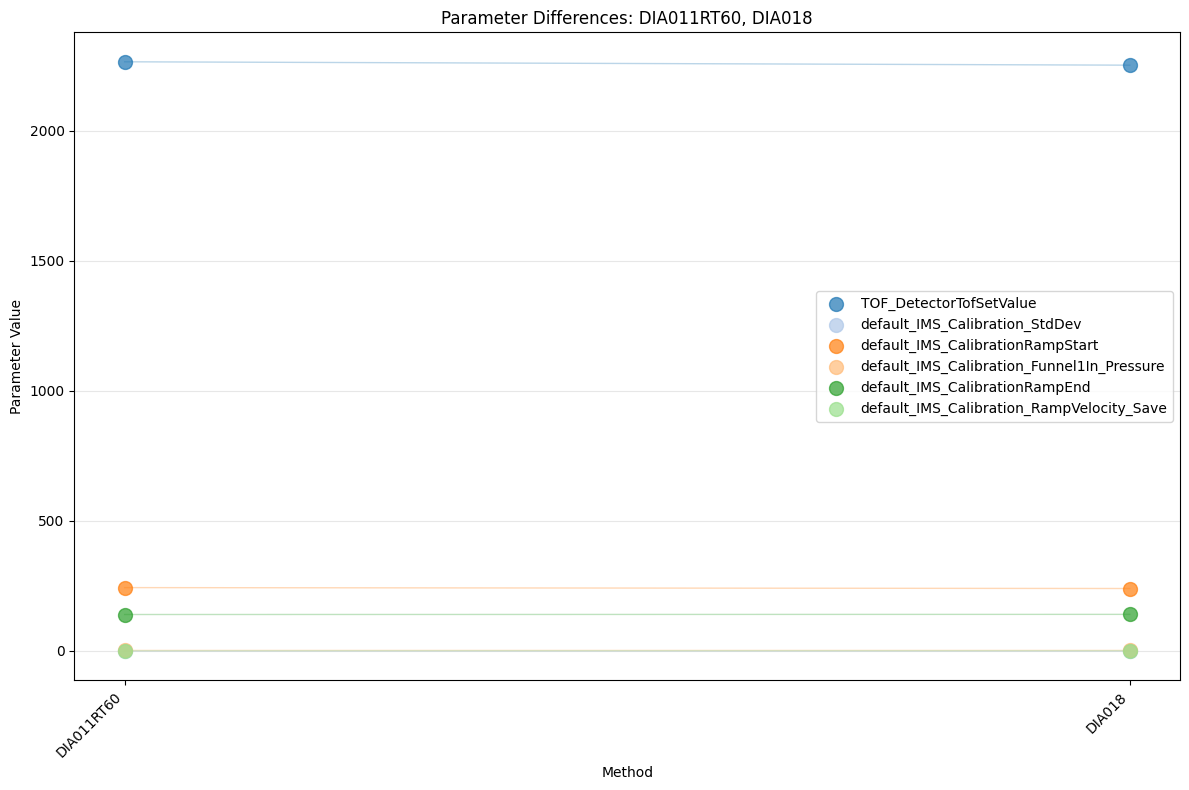

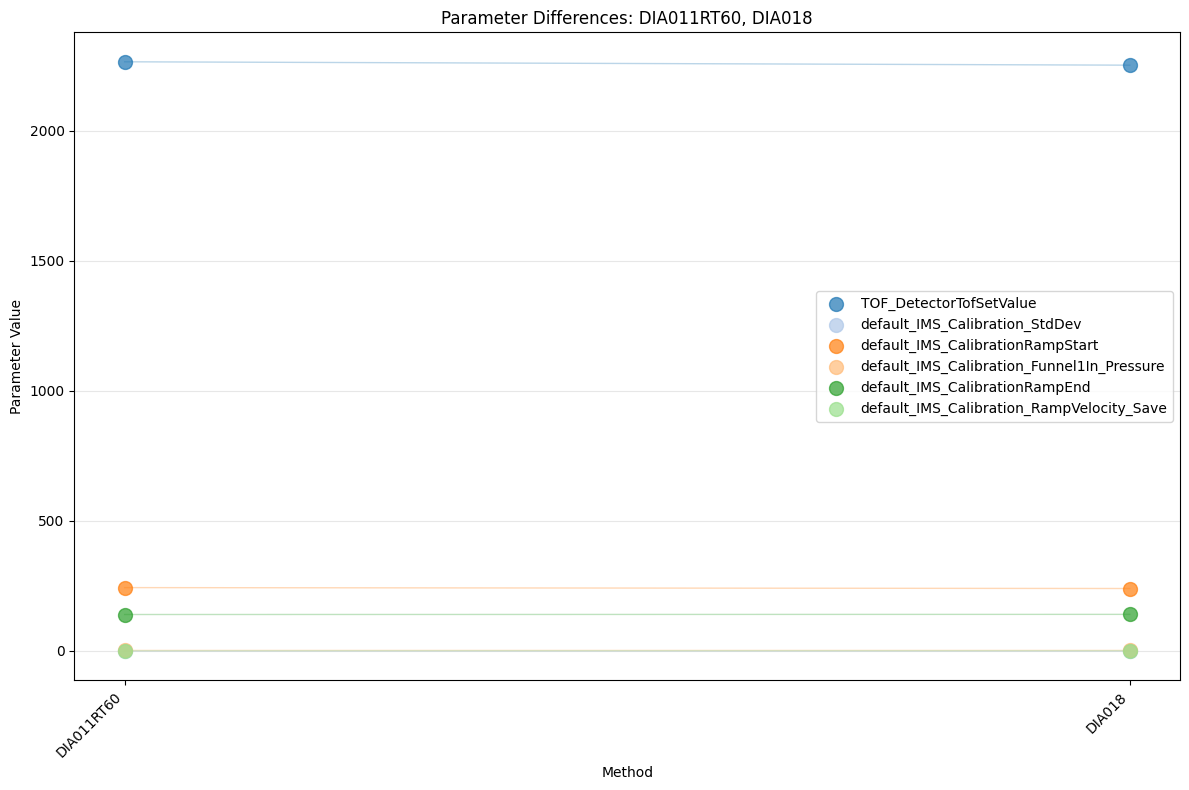

In [27]:
mscollection.plot_differences(method_names = ['DIA011RT60',
                                              'DIA018'],
                                              
)

### Plot DIA Windows

In [68]:
methods = ['DIA60msW102', 'DIA75msW82', 'DIA50msW122', 'DIA011RT75expandedrange', 'DIA011RT75expandedrangeW83',
           'DIA60msW102_C2', 'DIA75msW82_C2', 'DIA50msW122_C2']

<Axes: title={'center': 'DIA Windows Overlay: DIA75msW82, DIA50msW122, DIA011RT75expandedrangeW83'}, xlabel='m/z', ylabel='1/K0 (Ion Mobility)'>

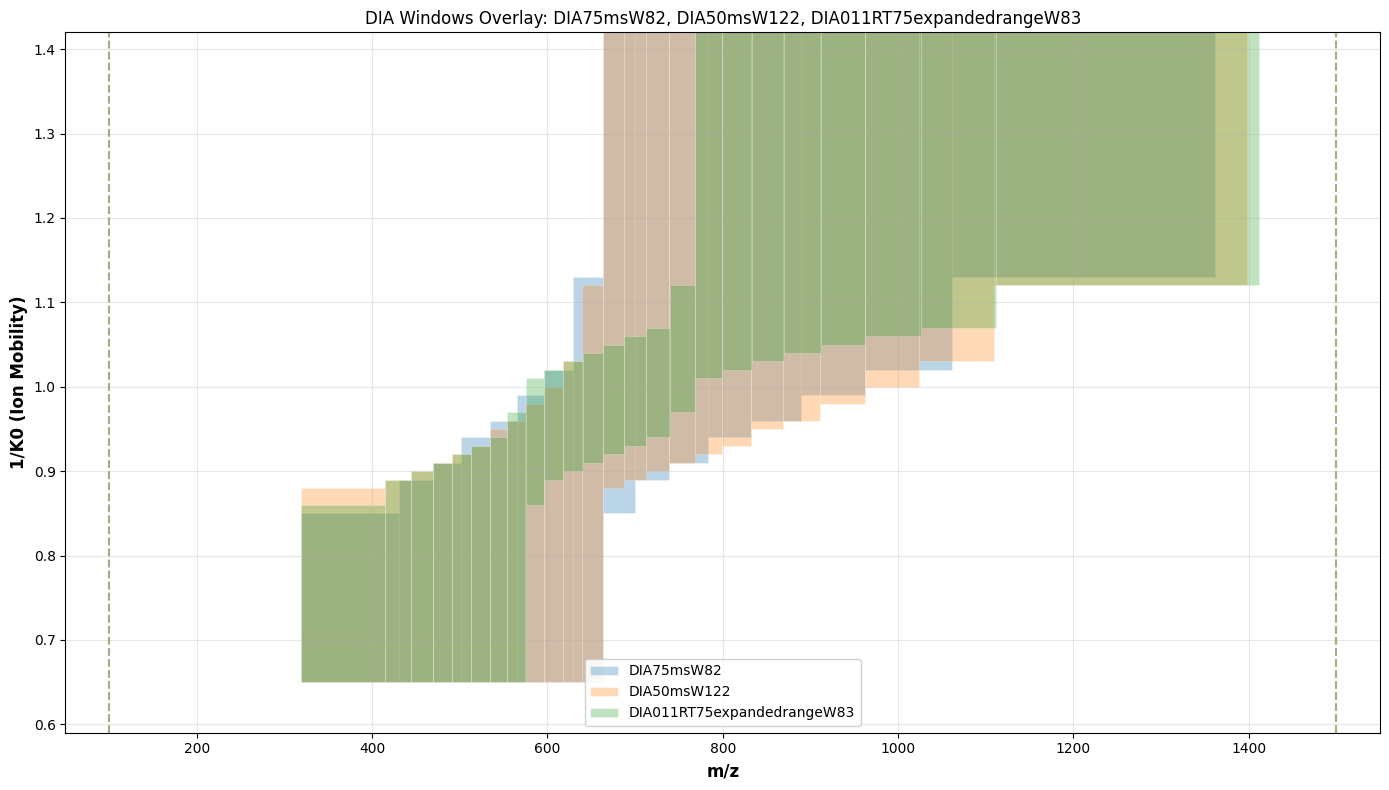

In [67]:
mscollection.plot_windows(['DIA75msW82', 'DIA50msW122', 'DIA011RT75expandedrangeW83'], color_by_method=True,
                    alpha=0.3,
                    # edge_color='white',
                    # figsize=(14, 8),
                    show_labels=False)

## Loading Searches

### BPS

In [22]:
# bpscollection = DiannCollection(log_file = f'{base}/MethodOpt/outputs/bpscollection.log')

In [23]:
# bpscollection.add_searches([f'{base}/MethodOpt/LCMSmethodAnalysis/SampleData/BPS/New Folder/{i}' for i in os.listdir(f'{base}/MethodOpt/LCMSmethodAnalysis/SampleData/BPS/New Folder')[:2]],
#                             search_type='bps',
#                             levels=['precursor'])

In [24]:
bpscollection = DiannCollection.from_file(f'{base}/MethodOpt/outputs/bpscollection.pkl')

Loaded collection from /hpc/projects/mass_spec/eileenwang/MethodOpt/outputs/bpscollection.pkl


In [ ]:
# map_lcms_methods(bpscollection, ['/hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/SampleData/Sequences/2026_01_lcmsmethodmapping.csv',
#                                  '/hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/SampleData/Sequences/2026_02.csv'])

In [25]:
# bpscollection.save(f'{base}/MethodOpt/outputs/bpscollection.pkl')

In [85]:
import zipfile
import pandas as pd
import os
from pathlib import Path

# Find all zip files in the BPS directory
zip_files = []
bps_path = f'{base}/MethodOpt/LCMSmethodAnalysis/SampleData/BPS'

# Recursively find all zip files
for root, dirs, files in os.walk(bps_path):
    for file in files:
        if file.endswith('.zip'):
            zip_files.append(os.path.join(root, file))

# Read metadata.csv from each zip file and combine into a single dataframe
metadata_dfs = []

for zip_path in zip_files:
    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            # Try to find metadata.csv in the zip file
            csv_files = [f for f in zip_ref.namelist() if f.endswith('metadata.csv')]
            
            if csv_files:
                # Read the first metadata.csv file found
                metadata_file = csv_files[0]
                with zip_ref.open(metadata_file) as f:
                    df = pd.read_csv(f)
                    # Add the zip file path as a column
                    df['zip_path'] = zip_path
                    metadata_dfs.append(df)

                
    except Exception as e:
        print(f"  ✗ Error processing {zip_path}: {e}")

# Combine all metadata dataframes
if metadata_dfs:
    combined_metadata = pd.concat(metadata_dfs, ignore_index=True)

else:
    print("No metadata files found!")
    combined_metadata = None

### Fragpipe

In [81]:
fpcollection = DiannCollection(log_file = f'{base}/MethodOpt/outputs/fpcollection.log')

In [82]:
fpcollection.add_searches(f"/hpc/projects/mass_spec/projects/SHEI004/search_result/fragpipe/EW/SHEI004_DIAonly/workingDir", 
                               search_type='fragpipe', 
                               levels=['precursor'])

In [14]:
# fpcollection.save(f'{base}/MethodOpt/outputs/fpcollection.pkl')

Saved collection to /hpc/projects/mass_spec/eileenwang/MethodOpt/outputs/fpcollection.pkl


In [10]:
fpcollection = DiannCollection.from_file(f'{base}/MethodOpt/outputs/fpcollection.pkl')

Loaded collection from /hpc/projects/mass_spec/eileenwang/MethodOpt/outputs/fpcollection.pkl


In [ ]:
# Summary
# # summary = collection.summary_df()
# # print(summary)

### Combine Sample and Method

In [ ]:

# map_lcms_methods(fpcollection, '/hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/SampleData/Sequences/2026_01_lcmsmethodmapping.csv')

/hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/SampleData/Sequences/2026_01_lcmsmethodmapping.csv
/hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/SampleData/Sequences/2026_02.csv


### Plotting/Analysis

#### Checkign distribution of Values

In [42]:
def check_dist(ad, layer, samples=None, figsize=(10,6)):
    fig, ax = plt.subplots(figsize=figsize)
    df = ad.to_df(layer)
    if samples:
        df = df.loc[:, samples]

    df = df.melt(value_name=layer)

    for s in df.columns:
        sns.violinplot(data = df, x = 'File.Name', y = layer, ax=ax)
    
    plt.xticks(rotation=90)

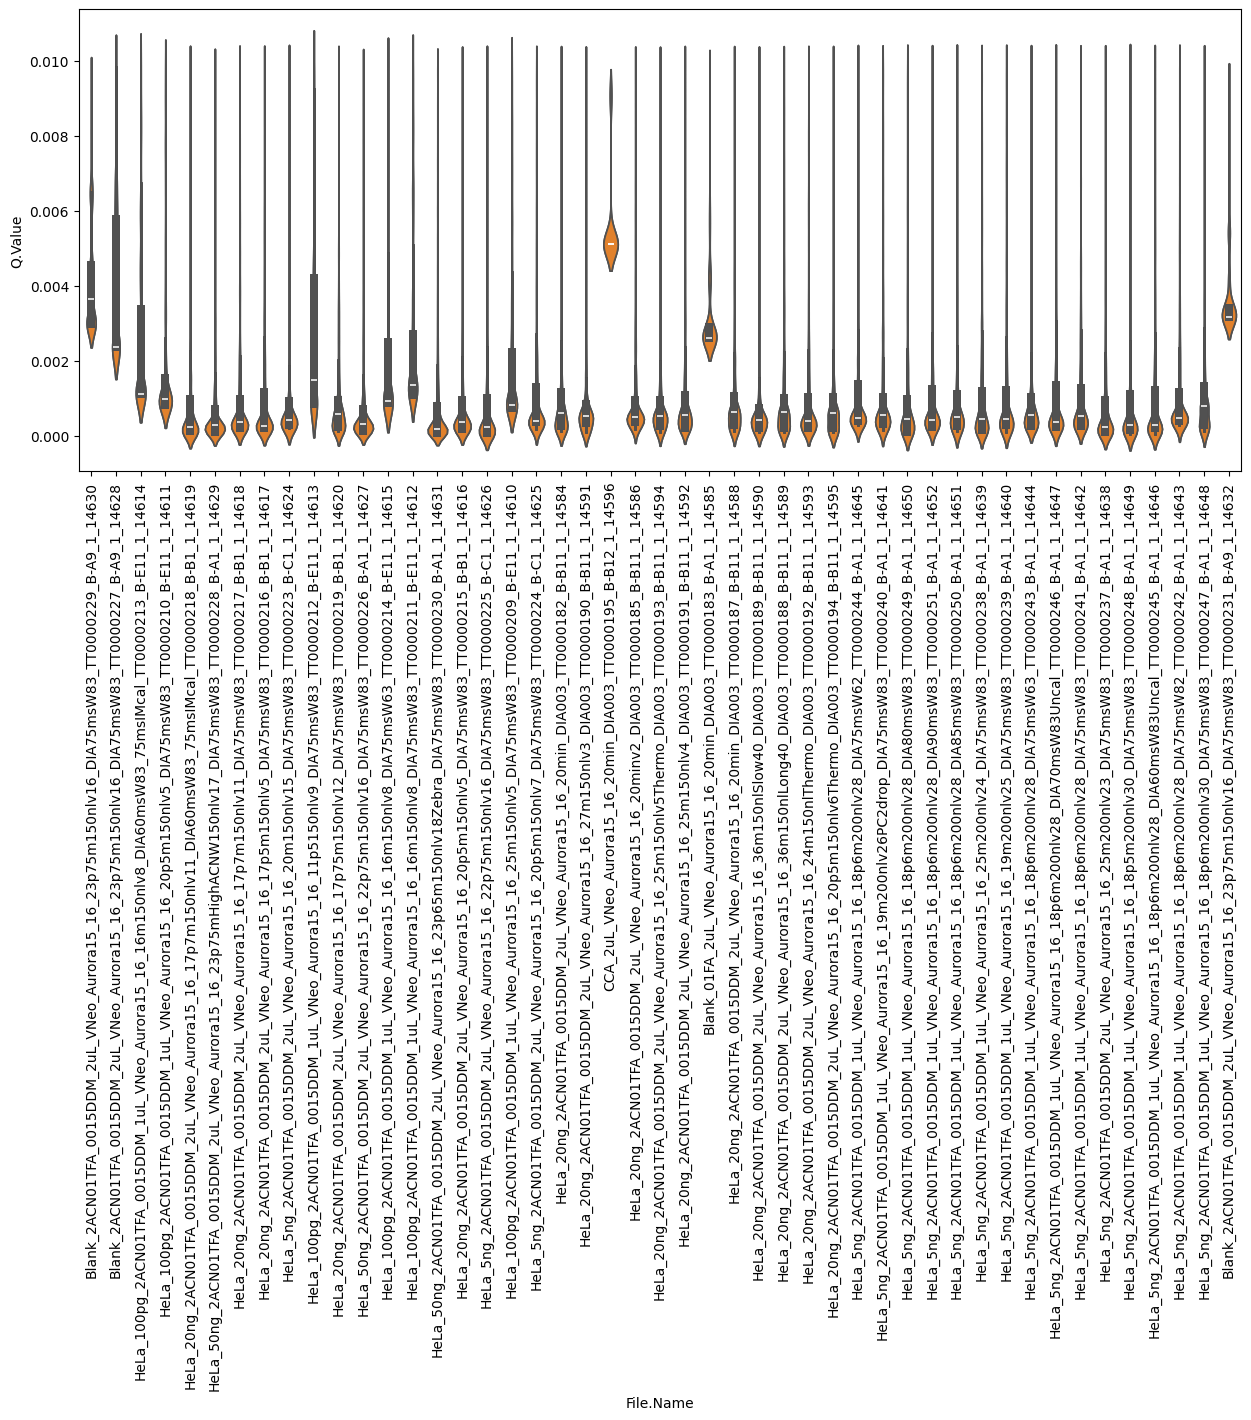

In [44]:
check_dist(bpscollection.data['precursor'], 'Q.Value', figsize=(15,6))

#### Filtering 

* *are RT being shifted in the flow drop or are we losing peptides?
* how are they being shifted? earlier or later?

#### Plotting RT Diff

<Axes: xlabel='HeLa_50ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_19mv45_DIA50msW122_TT0000391_B-A6_1_14795', ylabel='Count'>

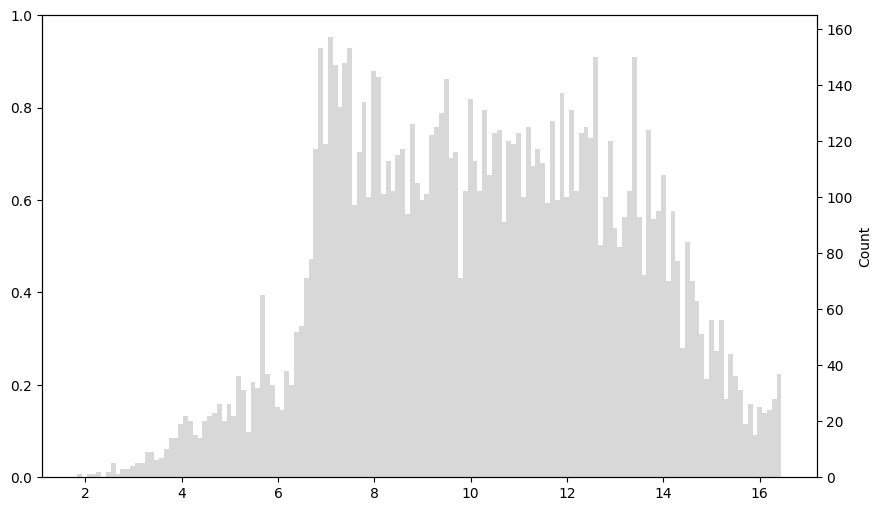

In [111]:
fig, ax = plt.subplots(figsize=(10,6))
ax2 = ax.twinx()

test4 = bpscollection.data['precursor'].to_df('RT')

sns.histplot(test4['HeLa_50ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_19mv45_DIA50msW122_TT0000391_B-A6_1_14795'], 
             ax=ax2, 
             alpha=0.3, 
             edgecolor=None, 
             color='grey', binwidth=0.1)

<Axes: xlabel='HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_17p5m150nlv5_DIA75msW83_TT0000216_B-B1_1_14617', ylabel='Count'>

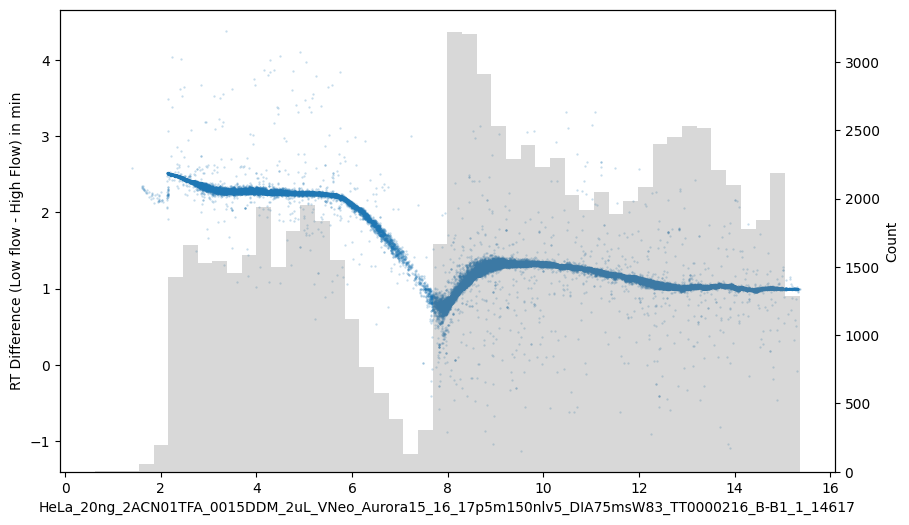

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
ax2 = ax.twinx()

test4 = bpscollection.data['precursor'].to_df('RT')
sns.scatterplot(x = test4['HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_17p5m150nlv5_DIA75msW83_TT0000216_B-B1_1_14617'],
                y= test4['HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_20p5m150nlv5_DIA75msW83_TT0000215_B-B1_1_14616'] - test4['HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_17p5m150nlv5_DIA75msW83_TT0000216_B-B1_1_14617'] - 2,
                y= test4['HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_20p5m150nlv5_DIA75msW83_TT0000215_B-B1_1_14616'] - test4['HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_17p5m150nlv5_DIA75msW83_TT0000216_B-B1_1_14617'] - 2,
                s=2,
                alpha=0.25,
                edgecolor=None,
                ax=ax)
ax.set_ylabel('RT Difference (Low flow - High Flow) in min')
sns.histplot(test4['HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_17p5m150nlv5_DIA75msW83_TT0000216_B-B1_1_14617'] , ax=ax2, alpha=0.3, edgecolor=None, color='grey')

<Axes: >

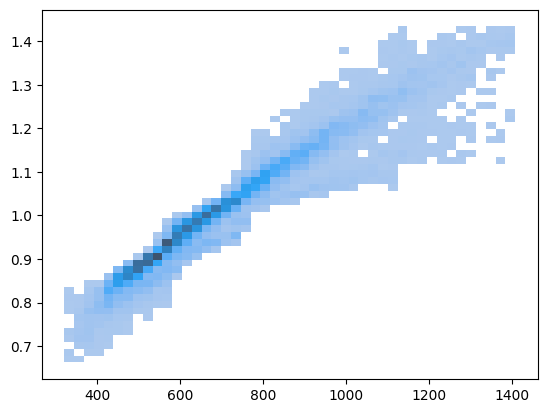

In [47]:
sns.histplot(x=test3.layers['Precursor.Calibrated.Mz'].flatten(), 
             y= test3.layers['Exp.1/K0'].flatten())

<Axes: ylabel='Count'>

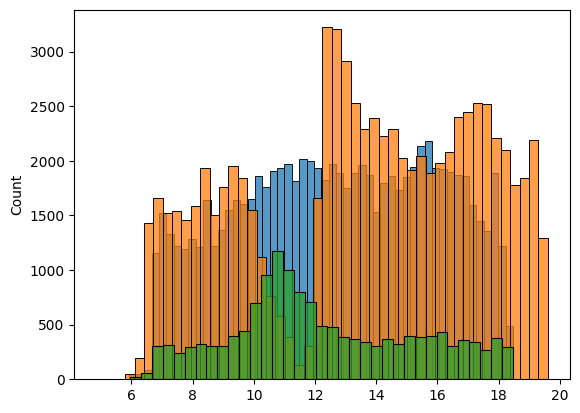

In [64]:
sns.histplot(test2[:, test2.var['hystar_index'].isin(['14616'])].layers['RT'].flatten())
sns.histplot(test2[:, test2.var['hystar_index'].isin(['14617'])].layers['RT'].flatten() + 4.25)

sns.histplot(test3.layers['RT'].flatten()) 

/hpc/mydata/eileen.wang/anaconda/25.3.1/x86_64/envs/methodanalysis/lib/python3.11/site-packages/anndata/_core/anndata.py:1813: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


<Axes: ylabel='Count'>

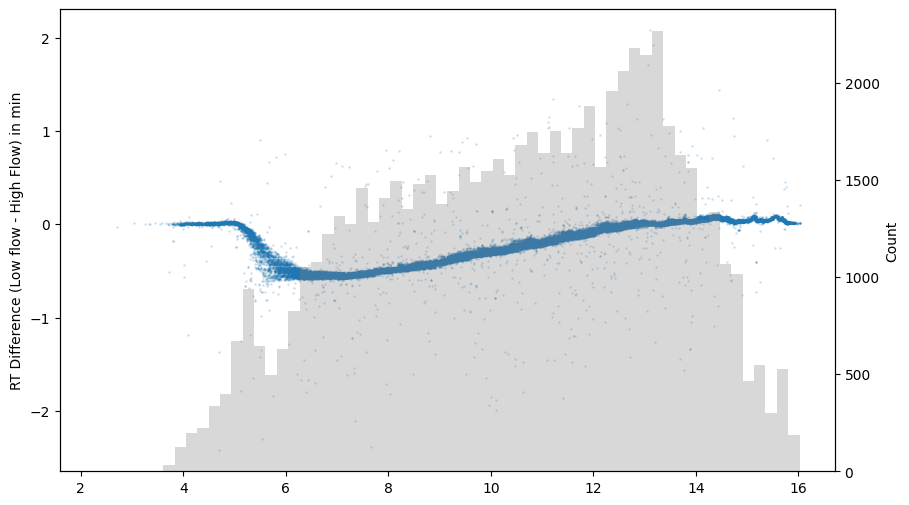

In [172]:
fig, ax = plt.subplots(figsize=(10,6))
ax2 = ax.twinx()

test = bpscollection.data['precursor'].copy()
sns.scatterplot(x = test[:, test.var['hystar_index'].isin(['14648'])].layers['RT'].flatten(),
                y= test[:, test.var['hystar_index'].isin(['14648'])].layers['RT'].flatten() - test[:, test.var['hystar_index'].isin(['14642'])].layers['RT'].flatten(),
                s=2,
                alpha=0.25,
                edgecolor=None,
                ax=ax)
ax.set_ylabel('RT Difference (Low flow - High Flow) in min')
sns.histplot(test[:, test.var['hystar_index'].isin(['14648'])].layers['RT'].flatten(), ax=ax2, alpha=0.3, edgecolor=None, color='grey')

#### Elution Param + Dist Mapping

In [126]:
df = elution_param(lccollection, bpscollection, 'HeLa_5ng_2ACN01TFA_0015DDM_1uL_VNeo_Aurora15_16_18p6m200nlv30_DIA75msW83_TT0000247_B-A1_1_14648')

Total volume passed at rt_min (2.28 min): 1142.81 nL
1142.8073404285715


/hpc/mydata/eileen.wang/anaconda/25.3.1/x86_64/envs/methodanalysis/lib/python3.11/site-packages/anndata/_core/anndata.py:1813: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


<Axes: title={'center': 'Gradient Comparison: 18p6m200nlv30'}, xlabel='time [min]', ylabel='Value [%]'>

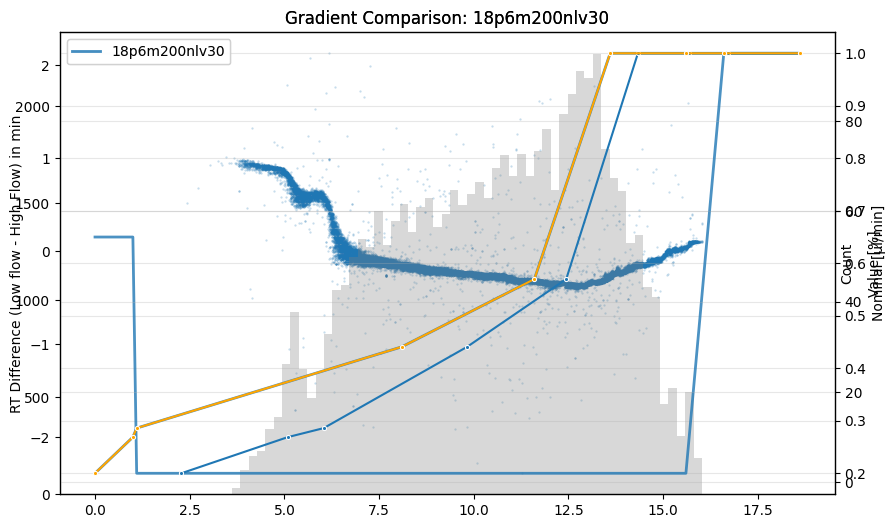

In [197]:
fig, ax = plt.subplots(figsize=(10,6))
ax2 = ax.twinx()
ax3 = ax.twinx()
ax4 = ax2.twinx()
sns.scatterplot(x = test[:, test.var['hystar_index'].isin(['14648'])].layers['RT'].flatten(),
                y= test[:, test.var['hystar_index'].isin(['14648'])].layers['RT'].flatten() - test[:, test.var['hystar_index'].isin(['14649'])].layers['RT'].flatten(),
                s=2,
                alpha=0.25,
                edgecolor=None,
                ax=ax)
ax.set_ylabel('RT Difference (Low flow - High Flow) in min')
sns.histplot(test[:, test.var['hystar_index'].isin(['14648'])].layers['RT'].flatten(), ax=ax2, alpha=0.3, edgecolor=None, color='grey')
# sns.histplot(test[:, test.var['hystar_index'].isin(['14649'])].layers['RT'].flatten(), ax=ax2, alpha=0.3, edgecolor=None, color='blue')


lccollection.plot_gradients(['18p6m200nlv30'], y_cols = ['Neo.PumpModule.Pump.Flow.Nominal [µl/min]'], ax = ax3)
lccollection.plot_gradients(['18p6m200nlv30'], y_cols = ['Neo.PumpModule.Pump.%B.Value [%]'], ax = ax4)

sns.lineplot(data = df, x = 'Actual Time to Elute Nominal %B (min)', y='Neo.PumpModule.Pump.%B.Value [%]', ax=ax4, marker='.')
sns.lineplot(data = df, x = 'time [min]', y='Neo.PumpModule.Pump.%B.Value [%]', ax=ax4, color='orange', marker='.')

#### Filtering/Counting Workshop

In [17]:
sc.pp.filter_cells(test, min_genes=0) # number of samples in which a given feature is quantified, based on X
sc.pp.filter_genes(test, min_cells=0) # number of features quantified in a given sample, based on X

In [ ]:
filter_mask(test, 
            filter_name = 'mask', 
            strict=False, 
            layer_threshold={'Q.Value': (0.01, 'max'),
                             'Lib.Q.Value': (0.01, 'max'), 
                             'Precursor.Quantity': (0, 'min')})

#### Gradients

<Axes: title={'center': 'Gradient Comparison: 25m200nlv24, 18p6m200nlv28drop'}, xlabel='time [min]', ylabel='Nominal [µl/min]'>

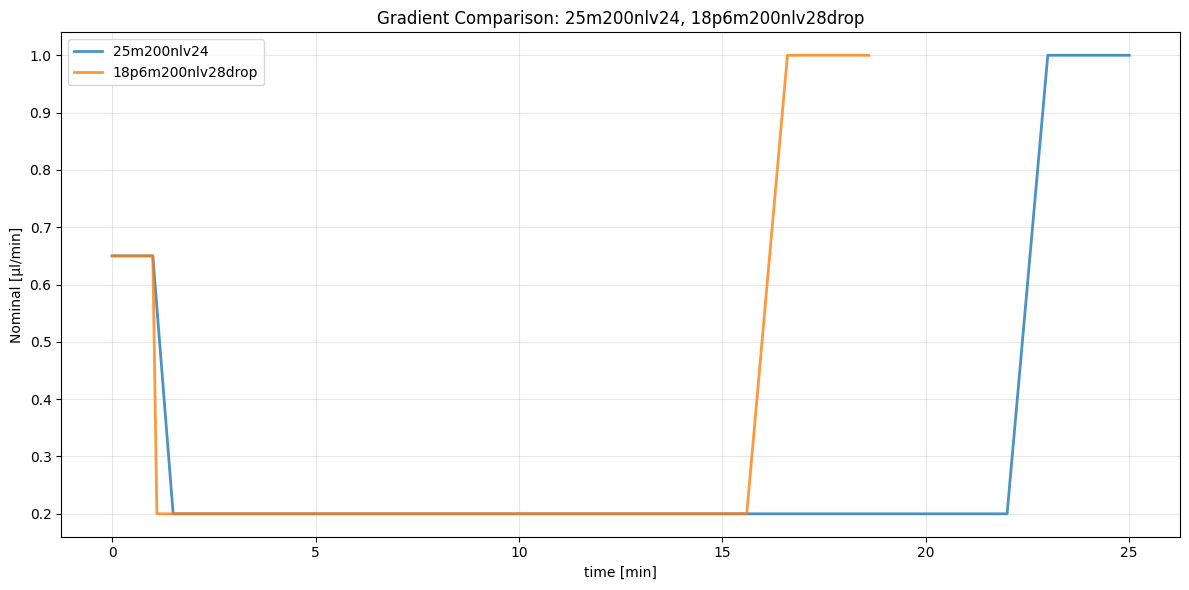

In [ ]:
lccollection.plot_gradients(['25m200nlv24', '18p6m200nlv28drop'], y_cols = ['Neo.PumpModule.Pump.Flow.Nominal [µl/min]'])

#### Ion Mobility Errir

(-0.2, 0.2)

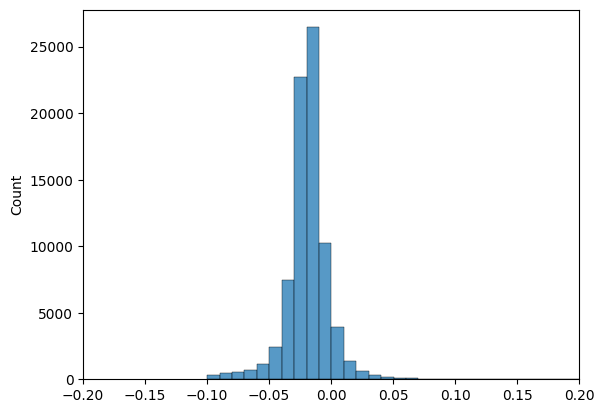

In [66]:
sns.histplot((sample.layers['Lib.1/K0'] - sample.layers['Exp.1/K0']).flatten(), binwidth =0.01)
plt.xlim(-0.2, 0.2)

#### Precursors vs MZ

## Plotter OBject

In [231]:
pl = Plotter()

#### MZ/IM

/hpc/mydata/eileen.wang/anaconda/25.3.1/x86_64/envs/methodanalysis/lib/python3.11/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 's'
  cset = contour_func(


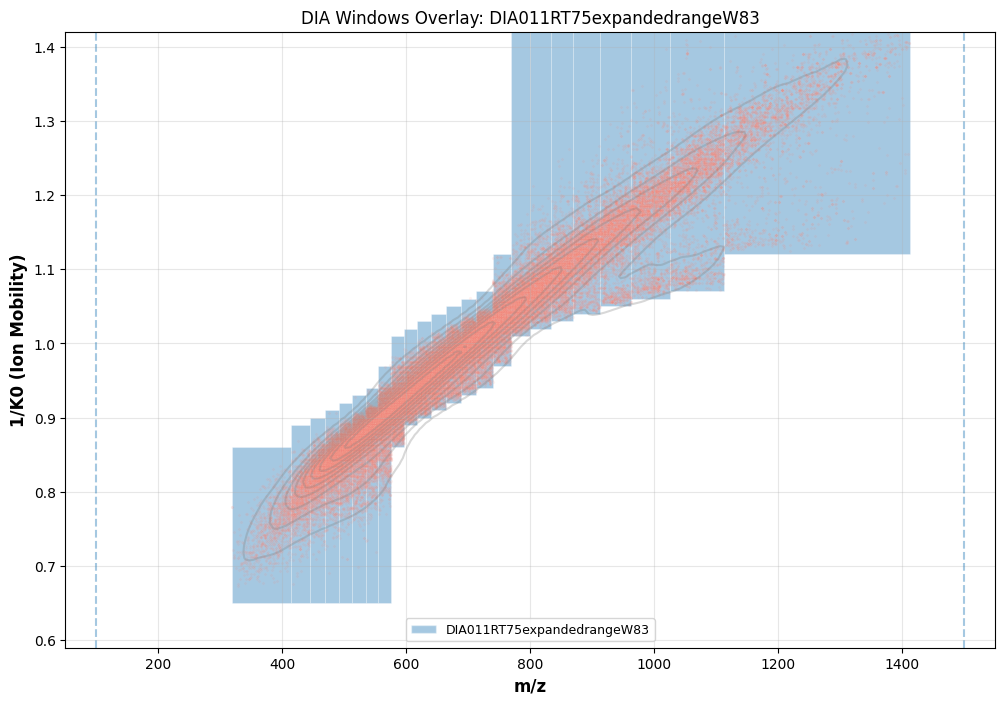

In [232]:
pl.plot_precursor_mz_im(bpscollection.data['precursor'],
                        'HeLa_5ng_2ACN01TFA_0015DDM_1uL_VNeo_Aurora15_16_18p6m200nlv30_DIA75msW83_TT0000247_B-A1_1_14648', 
                        mscollection, 
                        hue=None)

/hpc/mydata/eileen.wang/anaconda/25.3.1/x86_64/envs/methodanalysis/lib/python3.11/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 's'
  cset = contour_func(


TypeError: unhashable type: 'Series'

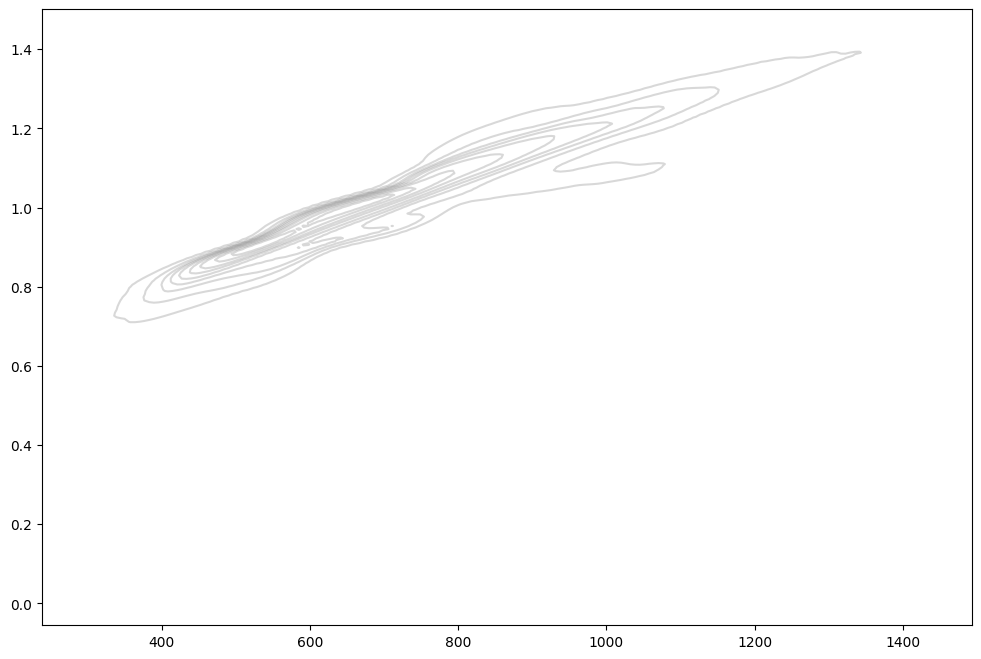

In [236]:
pl.plot_precursor_mz_im(bpscollection.data['precursor'],
                        'HeLa_50ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_23p65m150nlv18Zebra_DIA75msW83_TT0000230_B-A1_1_14631', 
                        mscollection, 
                        hue=None)

### Plotting Differences
* Analyzing bias introduced by the LC gradient

#### IM vs RT

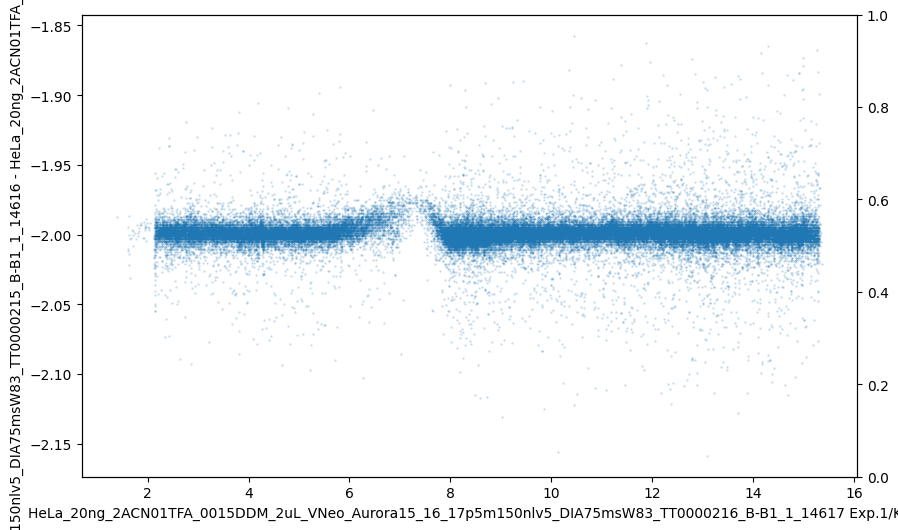

In [219]:
fig, ax = plt.subplots(figsize=(10,6))
ax2 = ax.twinx()

pl.scatterplot_difference(bpscollection.data['precursor'],
                          'HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_17p5m150nlv5_DIA75msW83_TT0000216_B-B1_1_14617',
                          'HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_20p5m150nlv5_DIA75msW83_TT0000215_B-B1_1_14616',
                          layer = 'Exp.1/K0',
                          x='RT',
                          ax = ax,
                          y_shift=2)

# sns.histplot(test4['HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_17p5m150nlv5_DIA75msW83_TT0000216_B-B1_1_14617'] , ax=ax2, alpha=0.3, edgecolor=None, color='grey')

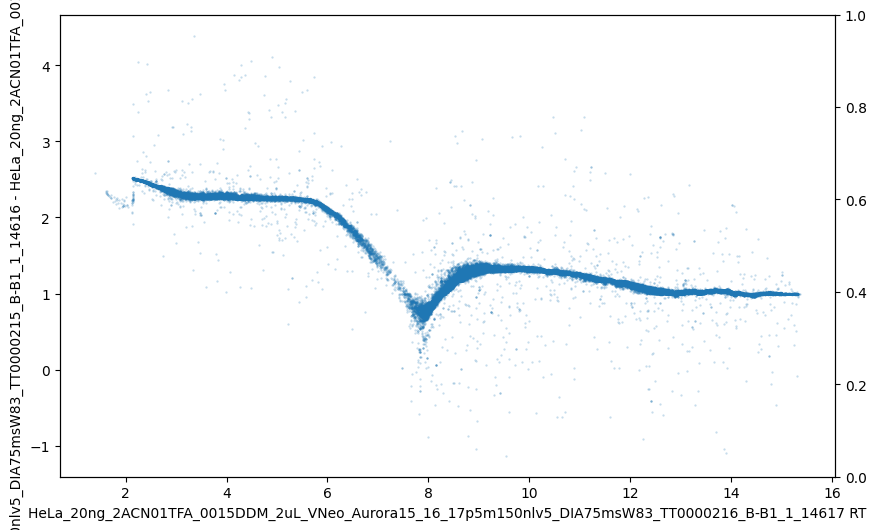

In [221]:
fig, ax = plt.subplots(figsize=(10,6))
ax2 = ax.twinx()

pl.scatterplot_difference(bpscollection.data['precursor'],
                          'HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_17p5m150nlv5_DIA75msW83_TT0000216_B-B1_1_14617',
                          'HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_20p5m150nlv5_DIA75msW83_TT0000215_B-B1_1_14616',
                          layer = 'RT',
                          ax = ax,
                          y_shift=2)

#### Calculating Coverage

In [ ]:
sample_adata = bpscollection.data['precursor'][:, 'sample_name']
dia_windows = mscollection['method_name'].get_dia_windows()

coverage_df = analyze_sample_coverage(sample_adata, dia_windows)
summary = summarize_coverage(coverage_df)

print(f"Coverage: {summary['coverage_rate']:.1f}%")
print(f"Covered: {summary['covered_precursors']} / {summary['total_precursors']}")

summary

# Analyzing Methods

1. How many precursors are being collected/detected per cycle?
2. How many precusors are being collected per unit time?
3. What percentage of precursors do our DIA windows collect?
   * Which precursors does it leave out?
   * Evaluating window size vs precursors actually in a window per unit time? 
4. What is the difference in number of precursors detected per sample/run?
   * How do they plot in terms of RT, IM, MZ, etc
5. Carryover?
   * % of total intensity 
   * % vs intensity in previous sample
   * properties of carrover/distribution vs RT